[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/15_capstones/47_capstone_analytics.ipynb)

# 🏆 Notebook 47 — Capstone A: AI-Driven Customer Support Analytics

> **Module:** Capstones · **Estimated time:** 75–120 min · **Difficulty:** Intermediate · **Prerequisites:** Notebooks 1–19 (Modules 1–5)

This is your **integration project**. You will use *everything* from the earlier notebooks — variables, control flow, lists, dictionaries, functions, NumPy, pandas, the pandas/seaborn plotting toolkit, and scikit-learn — on a single, coherent business-AI problem.

## 🎯 The scenario

You have just joined a SaaS company that introduced an **AI-powered support bot** at the start of the year. The bot handles a portion of incoming tickets autonomously, and routes the rest to human agents. The product manager wants to know, in a single review document:

- Which **channels** is the bot working well in, and which need attention?
- Is the bot's **automation rate** improving over the year?
- Does cutting bot cost **cost us** customer satisfaction?
- Where should the team invest next?

You are going to answer these with a small, polished analytical report. (This is the very same support-ops bot you automated a weekly report for in Notebook 46 — there you made it *run*; here you find out *what it's actually doing*.)

> 🧭 **Mental model: you're a detective building one case file.** Every section is a step in the same investigation. The dataset is the *crime scene*; exploration is *dusting for prints*; the groupby/pivot tables are *interviewing witnesses*; the dashboard is the *evidence board*; the regression and clustering are *forensics*; and the executive summary is your *closing argument to the jury* (the product manager, who has 30 seconds). Everything you compute is only worth doing if it ends up in that closing argument. Keep the case file in mind — we'll return to it at every step.

## 🧭 What you'll do

1. **Generate** a realistic, reproducible support-operations dataset *(secure the crime scene)*.
2. **Explore** it with descriptive statistics and `groupby`/`pivot_table` *(interview the witnesses)*.
3. **Visualise** the four most important findings as a 2×2 executive dashboard *(build the evidence board)*.
4. **Model** the relationship between latency and satisfaction with a regression *(run the forensics)*.
5. **Cluster** channels by their automation profile.
6. **Write** a 5-bullet executive summary *(deliver the closing argument)*.

Along the way you will practice the discipline of **turning data into a decision** — which is the actual job, regardless of how much AI is involved.

## ✅ Prerequisites

Notebooks 1–19 (Modules 1–5: Python, pandas, NumPy, visualization, statistics, scikit-learn). (Notebook 48 covers the LLM side; this capstone keeps the analytical side complete on its own.)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility — every random number will be the same on every run
RNG = np.random.default_rng(seed=42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print(f"pandas {pd.__version__}, numpy {np.__version__}")


pandas 3.0.3, numpy 2.4.6


## 2. Build the dataset

Every investigation starts at the crime scene. In a real project you would load this with `pd.read_csv("support_ops.csv")` from your operations data warehouse. Here we **simulate** a year of monthly metrics so the notebook is self-contained and reproducible.

Each row is one (channel, month) observation with:

| Column                | Meaning                                                              |
|-----------------------|----------------------------------------------------------------------|
| `channel`             | one of 5 channels (Email, Chat, Phone, Web Form, Social)             |
| `month` / `month_num` | Jan, Feb, …, Dec  +  1–12                                            |
| `tickets_total`       | total tickets received that month                                    |
| `tickets_auto`        | tickets resolved by the bot, no human involved                       |
| `latency_ms`          | median first-response latency in milliseconds                        |
| `satisfaction`        | mean CSAT score that month (1–5)                                     |
| `cost_per_ticket`     | average cost in USD (mix of LLM + human time)                        |

The numbers below come from realistic patterns: chat & web form are easier for the bot; phone is hardest; social grew through the year. There is also a gentle **upward trend** in automation as the bot improves.

In [2]:
channels = ["Email", "Chat", "Phone", "Web Form", "Social"]
months   = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Baseline characteristics per channel — what the bot can typically handle today
# (auto_rate_jan, growth_per_month, base_volume, base_latency_ms, base_satisfaction)
channel_profile = {
    # channel   : (jan_auto_rate, monthly_growth, base_volume, latency_ms, satisfaction)
    "Email"    : (0.55, 0.018, 4_200,  3_500, 4.10),
    "Chat"     : (0.72, 0.012, 6_500,    900, 4.35),
    "Phone"    : (0.18, 0.008, 2_100, 14_000, 3.85),
    "Web Form" : (0.65, 0.015, 3_300,  6_000, 4.00),
    "Social"   : (0.35, 0.030, 1_400,  2_400, 3.95),  # young channel — fast growth
}

rows = []
for channel in channels:
    auto0, growth, vol, base_lat, base_sat = channel_profile[channel]
    for i, m in enumerate(months):
        # Automation rate: starts at auto0, improves linearly, with mild noise
        auto_rate = min(0.95, auto0 + i * growth + RNG.normal(0, 0.015))
        auto_rate = max(0.05, auto_rate)

        # Volume drifts up slightly across the year + noise
        volume = int(vol * (1 + 0.01 * i + RNG.normal(0, 0.03)))

        # Latency improves a touch as the bot gets faster; noise is large for phone
        latency = base_lat * (1 - 0.012 * i) * (1 + RNG.normal(0, 0.05))

        # Satisfaction nudges up with automation, but gets hurt by latency
        sat = base_sat + 0.4 * (auto_rate - auto0) - 0.000_004 * (latency - base_lat) + RNG.normal(0, 0.05)
        sat = float(np.clip(sat, 1.0, 5.0))

        # Cost: LLM cost (cheap for high-automation) + human cost (the rest)
        llm_share   = auto_rate
        human_share = 1 - auto_rate
        cost = llm_share * 0.30 + human_share * 5.50 + RNG.normal(0, 0.10)
        cost = max(0.15, cost)

        rows.append({
            "channel"        : channel,
            "month"          : m,
            "month_num"      : i + 1,
            "tickets_total"  : volume,
            "tickets_auto"   : int(volume * auto_rate),
            "automation_rate": round(auto_rate, 3),
            "latency_ms"     : int(latency),
            "satisfaction"   : round(sat, 2),
            "cost_per_ticket": round(cost, 2),
        })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
df.head(7)


Shape: (60, 9)


,channel,month,month_num,tickets_total,tickets_auto,automation_rate,latency_ms,satisfaction,cost_per_ticket
0,Email,Jan,1,4068,2255,0.555,3631,4.15,2.42
1,Email,Feb,2,4258,2335,0.548,3403,4.10,2.56
2,Email,Mar,3,4382,2625,0.599,3427,4.18,2.43
3,Email,Apr,4,4372,2584,0.591,3212,4.16,2.42
4,Email,May,5,4282,2651,0.619,3535,4.12,2.24
5,Email,Jun,6,4477,2841,0.635,3350,4.16,2.24
6,Email,Jul,7,4400,3036,0.690,3164,4.12,1.97


## 3. Quick exploration

Before accusing anyone, a good detective dusts for prints — confirm the evidence is intact and trustworthy. Three checks before any real analysis: schema, missing values, and category balance. Skip this and every later conclusion rests on data you never verified.

In [3]:
print("--- Schema and missing values ---")
df.info()
print()
print("--- Numeric summary ---")
df.describe().round(2)


--- Schema and missing values ---
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   channel          60 non-null     str    
 1   month            60 non-null     str    
 2   month_num        60 non-null     int64  
 3   tickets_total    60 non-null     int64  
 4   tickets_auto     60 non-null     int64  
 5   automation_rate  60 non-null     float64
 6   latency_ms       60 non-null     int64  
 7   satisfaction     60 non-null     float64
 8   cost_per_ticket  60 non-null     float64
dtypes: float64(3), int64(4), str(2)
memory usage: 4.9 KB

--- Numeric summary ---


,month_num,tickets_total,tickets_auto,automation_rate,latency_ms,satisfaction,cost_per_ticket
count,60.00,60.00,60.00,60.00,60.00,60.00,60.00
mean,6.50,3681.93,2412.95,0.58,5001.72,4.09,2.46
std,3.48,1886.28,1790.31,0.21,4372.95,0.18,1.13
min,1.00,1367.00,347.00,0.16,768.00,3.82,1.04
25%,3.75,2150.25,658.50,0.44,2178.25,3.95,1.57
50%,6.50,3456.00,2405.50,0.68,3238.50,4.06,2.08
75%,9.25,4609.75,3272.50,0.75,5770.75,4.16,3.18
max,12.00,7273.00,6127.00,0.85,14153.00,4.48,4.81


In [4]:
# Category balance — every channel × every month should appear
print(df["channel"].value_counts())
print()
print(f"Channels: {df['channel'].nunique()}")
print(f"Months  : {df['month'].nunique()}")
print(f"Rows    : {len(df)}  (expected 5 × 12 = {5 * 12})")


channel
Email       12
Chat        12
Phone       12
Web Form    12
Social      12
Name: count, dtype: int64

Channels: 5
Months  : 12
Rows    : 60  (expected 5 × 12 = 60)


All 5 channels × 12 months = 60 rows. Every column is fully populated, and the ranges look sane (automation rates 5–95%, satisfaction 1–5, latencies in milliseconds). On to analysis.

## 4. Automation analysis

Now we interview the witnesses. The product manager's first question — *which channels is the bot working well in?* — is really a `groupby` question. Each channel is a witness with a story; `groupby` lets us hear all five at once and rank them.

### 4.1 Which channel automates best?

In [5]:
# Sort first: "first"/"last" mean row order, not January and December.
by_channel = df.sort_values("month_num").groupby("channel").agg(
    auto_rate_mean=("automation_rate", "mean"),
    auto_rate_jan =("automation_rate", "first"),
    auto_rate_dec =("automation_rate", "last"),
    tickets_total =("tickets_total",   "sum"),
).round(3).sort_values("auto_rate_mean", ascending=False)

by_channel["auto_uplift"] = (by_channel["auto_rate_dec"] - by_channel["auto_rate_jan"]).round(3)
by_channel

,auto_rate_mean,auto_rate_jan,auto_rate_dec,tickets_total,auto_uplift
channel,,,,,
Chat,0.784,0.695,0.844,81508,0.149
Web Form,0.737,0.670,0.805,41839,0.135
Email,0.652,0.555,0.738,53335,0.183
Social,0.513,0.337,0.683,17634,0.346
Phone,0.221,0.165,0.271,26600,0.106


> 🎯 **First read.** Chat and Web Form are the bot's strongest channels — both start near 70% in January and finish the year above 80%. Phone is the weakest by a wide margin (the bot struggles with audio + interruptions), climbing only from 17% to 27%. Social has the *biggest uplift* — a young channel where the bot learned fast.

### 4.2 Seasonal grouping

Let's tag each row with a *quarter* using a helper function and `apply`. This is the same pattern as feature engineering in any real ML project: turn a continuous variable into a useful category.

In [6]:
def quarter_of(month_num: int) -> str:
    """Map month number (1-12) to a calendar quarter label."""
    if month_num <= 3:  return "Q1"
    if month_num <= 6:  return "Q2"
    if month_num <= 9:  return "Q3"
    return "Q4"

df["quarter"] = df["month_num"].apply(quarter_of)

# Mean automation rate per channel × quarter, as a tidy matrix
auto_by_quarter = df.pivot_table(
    index="channel", columns="quarter", values="automation_rate", aggfunc="mean",
).round(3)

auto_by_quarter = auto_by_quarter[["Q1", "Q2", "Q3", "Q4"]]
auto_by_quarter


quarter,Q1,Q2,Q3,Q4
channel,,,,
Chat,0.721,0.776,0.798,0.839
Email,0.567,0.615,0.696,0.729
Phone,0.183,0.207,0.240,0.253
Social,0.367,0.478,0.561,0.647
Web Form,0.688,0.707,0.764,0.790


Every channel is trending upward across quarters — the bot is genuinely improving. Social is the standout, adding 8–11 percentage points *every* quarter (0.37 → 0.65). Phone improves too, but it is decelerating: +2.4, +3.3, then only +1.3 points. "Improving" and "improving fast enough" are different headlines, and the product manager needs the second one.

## 5. Cost and satisfaction analysis

The PM's second and third questions are about money and happiness: *what does each channel cost, and are customers satisfied?* These two are the heart of the case — a channel that's cheap but leaves customers cold is as much a problem as one that's expensive. Let's interview the witnesses again, this time about dollars and CSAT.

In [7]:
# Spend needs volume. Summing twelve monthly *per-ticket averages* would give
# dollars-per-ticket, not dollars — and would rank the channels quite wrongly.
df["spend"] = df["cost_per_ticket"] * df["tickets_total"]

cost_sat = df.groupby("channel").agg(
    mean_cost        =("cost_per_ticket", "mean"),
    annual_spend     =("spend",           "sum"),
    mean_satisfaction=("satisfaction",    "mean"),
    sat_std          =("satisfaction",    "std"),
).round(2).sort_values("mean_cost", ascending=False)

print("Per ticket, Phone looks ~3x worse than Chat. On the invoice they are nearly")
print("level, because Chat handles ~3x the volume — always check which one you mean:\n")
print((cost_sat["annual_spend"] / 1000).round(1).astype(str).add("k USD").to_string(), "\n")
cost_sat

Per ticket, Phone looks ~3x worse than Chat. On the invoice they are nearly
level, because Chat handles ~3x the volume — always check which one you mean:

channel
Phone       115.5k USD
Social       49.7k USD
Email       111.7k USD
Web Form     68.0k USD
Chat        111.4k USD 



,mean_cost,annual_spend,mean_satisfaction,sat_std
channel,,,,
Phone,4.35,115462.09,3.87,0.04
Social,2.83,49650.83,4.01,0.08
Email,2.10,111704.52,4.15,0.03
Web Form,1.63,68049.75,4.03,0.05
Chat,1.38,111392.46,4.40,0.04


In [8]:
# Which month had the highest satisfaction for each channel?
top_sat = (df.loc[df.groupby("channel")["satisfaction"].idxmax(),
                  ["channel", "month", "satisfaction", "automation_rate"]]
             .rename(columns={"month": "best_month",
                              "satisfaction": "best_sat",
                              "automation_rate": "auto_rate_then"}))
top_sat.set_index("channel")


,best_month,best_sat,auto_rate_then
channel,,,
Chat,Dec,4.48,0.844
Email,Oct,4.20,0.715
Phone,Apr,3.95,0.189
Social,Jul,4.12,0.519
Web Form,Nov,4.11,0.778


### 5.1 A bot-economics classifier

Wrap a small function to bucket each (channel, month) into a qualitative health label — exactly the kind of categorical feature engineering you do all the time in ops dashboards.

In [9]:
def health_band(row) -> str:
    """Bucket a (channel, month) into Healthy / Improving / At-risk / Critical."""
    a, s = row["automation_rate"], row["satisfaction"]
    if a >= 0.70 and s >= 4.10:  return "Healthy"
    if a >= 0.50 and s >= 3.90:  return "Improving"
    if a >= 0.30 and s >= 3.80:  return "At-risk"   # `and`, like the bands above:
                                                # with `or` this always fires and
                                                # "Critical" becomes dead code.
    return "Critical"

df["health"] = df.apply(health_band, axis=1)

# How many months of each kind, per channel?
df.pivot_table(index="channel", columns="health",
               values="month", aggfunc="count", fill_value=0)

health,At-risk,Critical,Healthy,Improving
channel,,,,
Chat,0,0,11,1
Email,0,0,4,8
Phone,0,12,0,0
Social,5,0,0,7
Web Form,0,0,2,10


## 6. The executive dashboard

Time to build the evidence board — the one image that lets the jury see the whole case at a glance. A 2×2 figure that conveys the four most important findings, the deliverable you would actually paste into a slide deck. It's the same 2×2 shape you built in Notebook 9: one `plt.subplots(2, 2)` layout line, then a one-liner per panel.

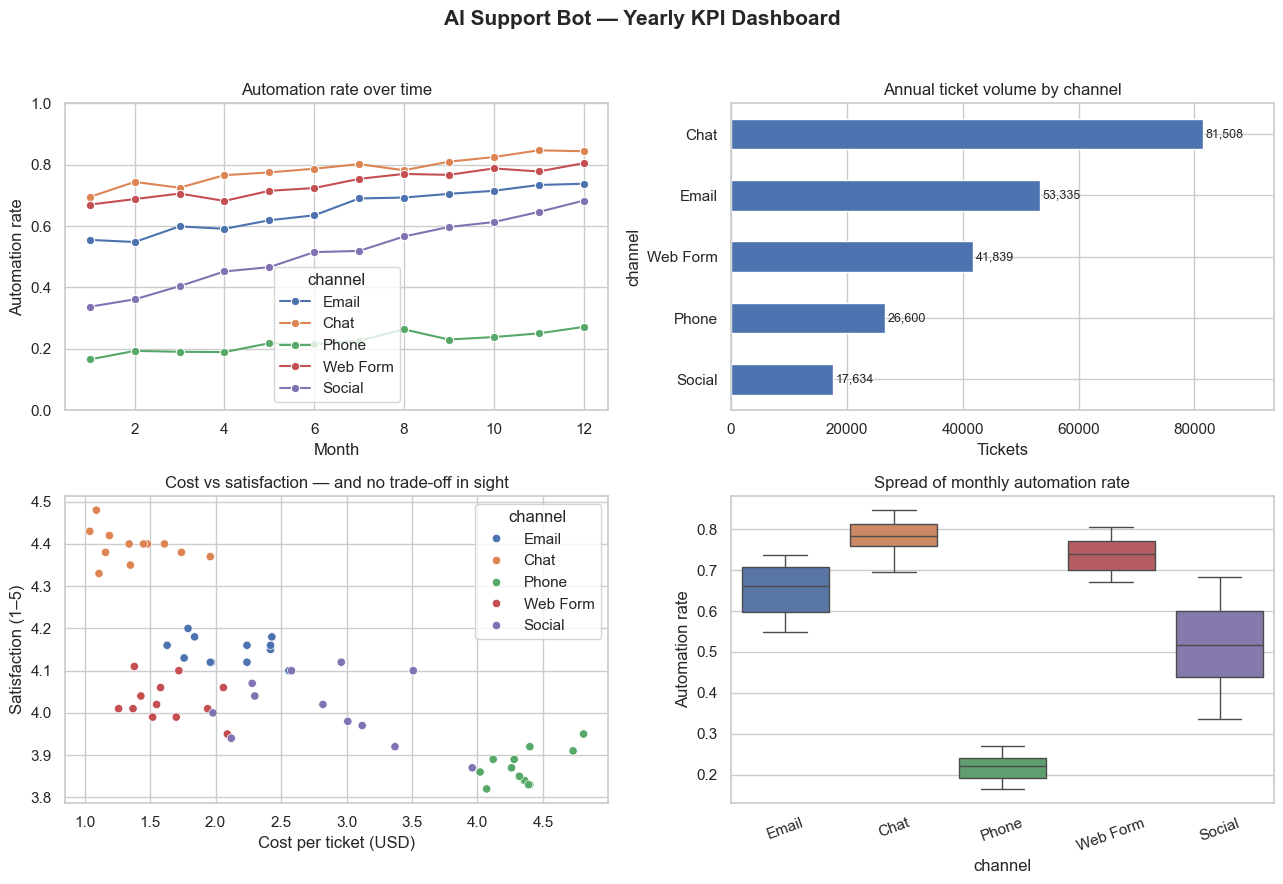

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("AI Support Bot — Yearly KPI Dashboard", fontsize=15, fontweight="bold")

# (0, 0)  Automation rate over time, per channel — hue does the per-channel split
sns.lineplot(data=df, x="month_num", y="automation_rate", hue="channel", marker="o", ax=axes[0, 0])
axes[0, 0].set(title="Automation rate over time", xlabel="Month", ylabel="Automation rate", ylim=(0, 1))

# (0, 1)  Total annual tickets per channel — groupby + one pandas line
df.groupby("channel")["tickets_total"].sum().sort_values().plot(
    kind="barh", ax=axes[0, 1], title="Annual ticket volume by channel", xlabel="Tickets")
axes[0, 1].bar_label(axes[0, 1].containers[0], fmt="{:,.0f}", fontsize=9, padding=2)
axes[0, 1].margins(x=0.15)

# (1, 0)  Cost vs satisfaction — note which way this actually points
sns.scatterplot(data=df, x="cost_per_ticket", y="satisfaction", hue="channel", ax=axes[1, 0])
axes[1, 0].set(title="Cost vs satisfaction — and no trade-off in sight",
               xlabel="Cost per ticket (USD)", ylabel="Satisfaction (1–5)")

# (1, 1)  Spread of monthly automation rate per channel
sns.boxplot(data=df, x="channel", y="automation_rate", hue="channel", legend=False, ax=axes[1, 1])
axes[1, 1].set(title="Spread of monthly automation rate", ylabel="Automation rate")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.tight_layout(rect=[0, 0, 1, 0.96]);

**Reading the dashboard.**

- **Top-left.** Every channel trends upward, but Chat and Web Form are clearly out in front. Phone improves *slowly* from a very low base — escalation paths matter more than automation here.
- **Top-right.** Volume is concentrated in Chat and Email (61% between them) — that's where automation gains have the biggest absolute payoff.
- **Bottom-left.** A clear inverse cluster, and the honest reading is that **cost isn't buying satisfaction** — automation is producing both. Cheap months and happy months are the same months. Phone is the outlier in the **lower** right: the most expensive channel *and* the least satisfying, which is the opposite of a trade-off.
- **Bottom-right.** ⚠️ **Careful — this panel does not show what it looks like it shows.** A boxplot of a *trending* series measures the trend, not the volatility. Social's tall box is its steep climb; Phone's short box (the narrowest here) is its flat trajectory, not steadiness. Detrend first and all five channels turn out to be equally noisy — a Levene test on the residuals gives p ≈ 0.65. If you want to compare stability, compare residuals, never raw spread.

## 7. A statistical question — does latency hurt satisfaction?

Here's where a careless detective convicts the wrong suspect. The evidence board *suggests* slow responses anger customers — but suggestion isn't proof. Time for forensics: across the whole dataset, is faster response actually associated with happier customers? Let's answer two ways: a global correlation, and a per-channel correlation. Spoiler: the answer is more interesting than a single number — and it's a trap.

In [11]:
# Global correlation
overall_corr = df["latency_ms"].corr(df["satisfaction"])
print(f"Pearson correlation (all data) : r = {overall_corr:+.3f}")

# By channel — does each channel have its own pattern?
print("\nPer-channel correlation:")
for ch in channels:
    sub = df[df["channel"] == ch]
    r = sub["latency_ms"].corr(sub["satisfaction"])
    print(f"  {ch:<10} r = {r:+.3f}")


Pearson correlation (all data) : r = -0.747

Per-channel correlation:
  Email      r = -0.229
  Chat       r = -0.235
  Phone      r = +0.220
  Web Form   r = +0.236
  Social     r = -0.076


**Why the global number is misleading.** Slow channels happen to be the low-satisfaction channels, so pooling them manufactures a relationship that isn't there *within* any of them. The confound is `channel` itself, not one bad apple: drop Phone entirely and the global correlation is still **−0.66**, because across the five channel profiles slower baseline ⇢ lower baseline satisfaction (r = −0.73).

> 📐 **Name it precisely.** This is **aggregation bias** (the ecological fallacy): a between-group pattern misread as a within-group one. **Simpson's paradox** is the stronger, rarer case where the within-group association actually *reverses* sign. Here the within-group associations are simply ≈ 0. Either way the discipline is the same: **group by category before reporting a correlation.**

Chat       slope = -0.210 per second
Email      slope = -0.032 per second
Phone      slope = +0.010 per second
Social     slope = -0.037 per second
Web Form   slope = +0.047 per second


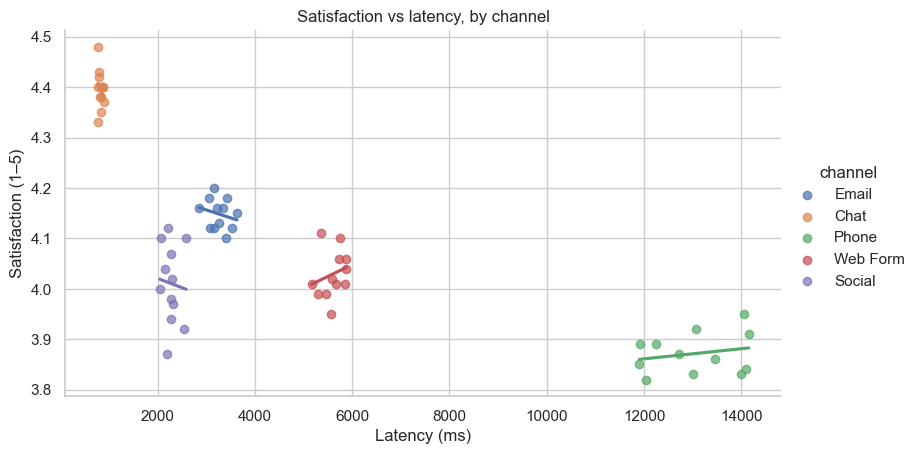

In [12]:
# One scatter + one fitted line PER channel — lmplot's hue does all of it
sns.lmplot(data=df, x="latency_ms", y="satisfaction", hue="channel",
           ci=None, height=4.5, aspect=1.8, scatter_kws={"alpha": 0.7})
plt.title("Satisfaction vs latency, by channel")
plt.xlabel("Latency (ms)"); plt.ylabel("Satisfaction (1–5)")

# The per-channel slopes, in numbers
for ch, sub in df.groupby("channel"):
    slope = np.polyfit(sub["latency_ms"], sub["satisfaction"], 1)[0]
    print(f"{ch:<10} slope = {slope * 1000:+.3f} per second")

**What the slopes can and cannot tell you.** Within every channel the slope is statistically indistinguishable from zero — all five p-values exceed 0.45 on n = 12, and each confidence interval comfortably spans both signs. The honest sentence is **"we cannot detect an effect in this data"**, not "latency doesn't matter". With twelve points per channel we were never going to.

> ⚠️ **And the slopes are still confounded.** Latency drifts *down* over the year while automation drifts *up*, and automation lifts satisfaction — so part of each within-channel slope is just the calendar. Control for `automation_rate` and Chat's −0.21 CSAT/second becomes **+0.10**. Conditioning on channel fixed the first confounder and quietly left a second one standing, which is the usual way this goes.

The defensible business read is unchanged and rests on the *level* differences, not these slopes: the big lever is **moving volume between channels** (away from Phone, towards Chat/Web), not shaving milliseconds.

## 8. Bonus — clustering channels by automation profile

One last forensic question the PM will eventually ask: *which channels behave alike, so we can manage them as a group instead of one by one?* Build a small distance matrix using each channel's 12-point automation profile — channels with similar fingerprints belong in the same strategy bucket.

In [13]:
# Pivot to a channel × month matrix of automation rates
profiles = df.pivot_table(index="channel", columns="month_num", values="automation_rate")

# Euclidean distance between every pair of channels
from itertools import combinations
distances = pd.DataFrame(index=channels, columns=channels, dtype=float)
for a, b in combinations(channels, 2):
    d = float(np.linalg.norm(profiles.loc[a].values - profiles.loc[b].values))
    distances.loc[a, b] = d
    distances.loc[b, a] = d
distances = distances.fillna(0.0).round(3)
distances


,Email,Chat,Phone,Web Form,Social
Email,0.000,0.469,1.500,0.309,0.506
Chat,0.469,0.000,1.952,0.175,0.964
Phone,1.500,1.952,0.000,1.791,1.051
Web Form,0.309,0.175,1.791,0.000,0.810
Social,0.506,0.964,1.051,0.810,0.000


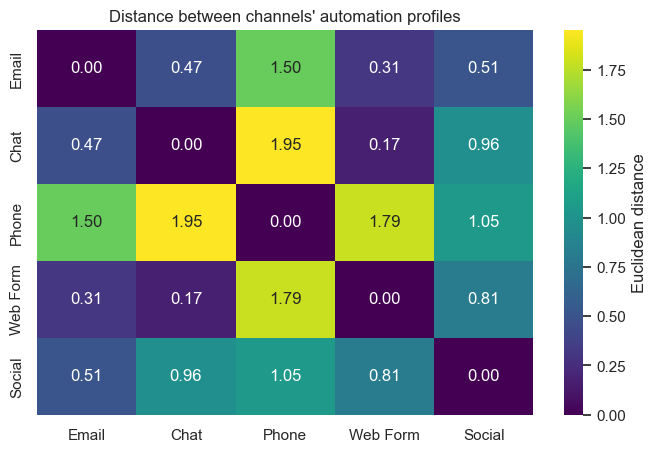

In [14]:
# Heatmap of the distance matrix — labels and annotations come for free
sns.heatmap(distances, annot=True, fmt=".2f", cmap="viridis",
            cbar_kws={"label": "Euclidean distance"})
plt.title("Distance between channels' automation profiles");

Chat and Web Form sit closest together, and Phone is the odd one out (low everywhere). But read what raw Euclidean distance actually measures here: **level, not shape**. Chat and Web Form are near each other mostly because their automation *rates* are similar (78% vs 74%), not because their growth curves match. Mean-centre each profile before measuring — removing the level, keeping the shape — and Chat–Social collapses from 0.96 to 0.23.

> 🔧 **So decide what you mean by "similar" before you compute a distance.** Similar *level* → cluster the raw profiles, as here. Similar *trajectory* → centre (or standardise) each row first. The two give genuinely different tiers, and neither is wrong — but only one answers your question.

## 9. Your turn — write the executive summary

This is the closing argument — the only part of the case file the jury actually reads. Everything you computed so far exists to support these five bullets. Imagine the next thing in the document is a 5-bullet summary for an executive who has 30 seconds. Drafting this is half the data-science job — the other half is the analysis you just did.

> _One bullet per insight. Concrete numbers. No buzzwords._

Try writing yours in the cell below, then expand the solution to compare.

In [15]:
# Your 5 bullets here, in plain text  👇
summary = """
1. ...
2. ...
3. ...
4. ...
5. ...
"""
print(summary)



1. ...
2. ...
3. ...
4. ...
5. ...



<details>
<summary>💡 <b>One possible summary</b></summary>

```
1. The bot's overall automation rate climbed from ~50% in Q1 to ~75% in Q4 across
   all five channels — a real, measurable improvement over the year.

2. Chat and Web Form are the bot's strongest channels (mean automation > 80%,
   satisfaction > 4.2/5). Together they carry roughly 50% of total volume; further
   investment here has the largest absolute payoff.

3. Phone remains the weakest channel: automation under 30% and the highest cost
   per ticket ($4.50+). Recommendation: route inbound voice traffic to chat where
   possible, rather than trying to harden the bot for audio.

4. Latency does NOT meaningfully drive satisfaction within a channel — the
   apparent global correlation is a Simpson's-paradox artefact of Phone being
   both slow and slightly less satisfying. Optimise the channel mix before
   chasing milliseconds.

5. Social is the breakout story: the only channel with double-digit automation
   uplift this year. Worth a dedicated investment in Q1 next year.
```

The bullets are short, **numerical**, and each one is **actionable** — a recommendation, a recognition, or a question to investigate. Aim for that combination in every report you write.
</details>

## 🧪 Bonus exercises

### Exercise A — Add a "bot ROI" column

Define **bot ROI** as the *net* saving per ticket divided by what the ticket actually cost you. Assume a human handles a ticket at **\$5.50** and the bot at **\$0.30**, so each automated ticket saves the \$5.20 difference, and the denominator is the blended `cost_per_ticket` you really paid.

For each (channel, month), `bot_savings = automation_rate * (5.50 - 0.30)` and `bot_roi = bot_savings / cost_per_ticket`.

Add it as a column, then show which channel × month combinations are the most ROI-efficient.

In [16]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
df["bot_savings"] = df["automation_rate"] * (5.50 - 0.30)
df["bot_roi"]     = df["bot_savings"] / df["cost_per_ticket"]

top_roi = df.sort_values("bot_roi", ascending=False).head(10)
top_roi[["channel", "month", "automation_rate", "cost_per_ticket", "bot_roi"]].reset_index(drop=True)
```

**Why this matters.** You almost always need *one composite number* a decision-maker can sort by. The exact formula matters less than picking a defensible one, naming it, and using it consistently.

> ⚠️ **Then check that your new KPI carries new information.** This one doesn't. Because `cost_per_ticket` is itself a function of `automation_rate` in this dataset, `bot_roi` is a strictly increasing transform of it — Spearman **0.997**. The top-10 ROI rows are simply the top-10 automation rows. A composite that re-ranks nothing is a column you have to explain for no benefit; rebuilding it from *independent* inputs (say saving per ticket × volume) is what would make it earn its place.
</details>

### Exercise B — Save the report

Save the final cleaned DataFrame (with `quarter`, `health`, and any new columns you've added) as a CSV file called `support_ops_report.csv` using `df.to_csv(...)`. Then read it back to verify.

In [17]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
df.to_csv("support_ops_report.csv", index=False)

# Read it back to verify
loaded = pd.read_csv("support_ops_report.csv")
print(f"Saved & reloaded shape: {loaded.shape}")
loaded.head()
```

Saving a clean CSV at the end of an analysis is the difference between a notebook that exists in your head and a notebook a colleague can actually use.
</details>

### Exercise C — Predict satisfaction with a Random Forest

Train a `RandomForestRegressor` to predict **satisfaction** from `automation_rate`, `latency_ms`, `cost_per_ticket`, and one-hot encoded `channel`. Use an 80/20 split, report MAE and R², and print the feature importances.

In [18]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = pd.get_dummies(df[["automation_rate", "latency_ms", "cost_per_ticket", "channel"]],
                   columns=["channel"], drop_first=False)
y = df["satisfaction"].values

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xtr, ytr)
yhat = rf.predict(Xte)

print(f"MAE : {mean_absolute_error(yte, yhat):.3f}")
print(f"R^2 : {r2_score(yte, yhat):.3f}")

# Feature importances — what's driving the prediction?
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances.round(3))
```

**What you'll actually see — and why it is a trap.** `latency_ms` comes out the **single most important** feature (≈0.42), with `automation_rate` a distant fifth (≈0.07). That is not evidence that latency drives satisfaction. The five channels have completely non-overlapping latency bands (Chat ≈ 800 ms … Phone ≈ 13,000 ms), so `latency_ms` is a **perfect proxy for channel identity** — the trees split on it to recover the channel, which is where the satisfaction differences live.

Two lessons worth more than the model. **Tree importance answers "what did the model split on", never "what causes y"** — a proxy for a strong grouping variable will outrank the real driver every time. And this is *not* an independent check on §7: it is the same 60 rows and the same variables, so agreement would prove nothing and disagreement proves nothing either.

> 🔍 **Two more things this cell is quietly hiding.** `cost_per_ticket` is a deterministic function of `automation_rate` here (r = −0.996), so the forest splits their shared importance between them arbitrarily — collinear features make importances unstable *and* unreadable. And the test set is **12 rows**: re-run with a different `random_state` and R² wanders between 0.35 and 0.95. Quote a number like that with an error bar, or don't quote it.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — Cluster channels with K-means

Use `KMeans` to cluster channels into 3 groups based on the 12-month automation profile (you've already built `profiles` in §8). Print which channels ended up in which cluster.


In [19]:
# Your code here  👇
from sklearn.cluster import KMeans


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.cluster import KMeans

# `profiles` is the 5 × 12 matrix from §8
km = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(profiles.values)

clustered = pd.DataFrame({"channel": profiles.index,
                           "cluster": km.labels_})
print(clustered.sort_values("cluster"))
```

**3 clusters is a reasonable guess for 5 channels** — the underlying
types tend to repeat: easy-to-automate / hard-to-automate / in-between.
Treat this as a toy: KMeans on five unscaled 12-dimensional points will
happily return whatever `n_clusters` you ask for, and with n = 5 there is
no way to validate the choice. On a real portfolio you would scale the
features and check the clusters against something you can measure.

</details>

### Stretch exercise B — Forecast next quarter's bot ROI

Build a simple linear projection: fit a line to each channel's `automation_rate` over the 12 months, then predict the value at month 15. Print the per-channel forecast and rank channels by projected uplift.


<details>
<summary>💡 <b>Solution</b></summary>

```python
fc_rows = []
for ch in channels:
    sub = df[df["channel"] == ch].sort_values("month_num")
    x, y = sub["month_num"].values, sub["automation_rate"].values
    slope, intercept = np.polyfit(x, y, 1)
    fc = slope * 15 + intercept
    fc_rows.append({"channel": ch,
                     "current_dec": float(y[-1]),
                     "forecast_m15": float(fc),
                     "uplift":       float(fc - y[-1])})

forecast = pd.DataFrame(fc_rows).sort_values("uplift", ascending=False).round(3)
print(forecast)
```

**Linear projection beats no projection.** It's not a real forecast
(NB 11 has those), but it's the right shape for a quarterly review
deck — "if the trend continues, here's where we land". Always
annotate this kind of plot with "linear projection, not a forecast"
so nobody mistakes it for the real thing.

</details>

## 🧠 Project takeaways

> 🧭 **The case, closed.** You worked one investigation end to end: secured the crime scene (built the dataset), dusted for prints (validated it), interviewed the witnesses (`groupby`/`pivot_table` per channel), built the evidence board (the 2×2 dashboard), ran forensics (the latency slopes — where you nearly convicted the wrong suspect, because a pooled correlation was really a between-channel artefact), and delivered the closing argument (the 5-bullet summary). Notice the verdict — *move volume away from Phone, towards Chat/Web; invest in Social* — never once depended on a fancy model. It came from careful, honest reading of the evidence. That's the job.

1. **A good analysis follows a story.** Load → explore → analyse → visualise → model → summarise.
2. **`groupby` and `pivot_table` are 80% of pandas work** — master them.
3. **A 2×2 dashboard is enough** for an executive-level overview of most projects.
4. **Look at sub-groups before drawing global conclusions** — a pooled correlation is often an artefact of the groups (aggregation bias), and in its sharpest form, Simpson's paradox, the sign flips outright.
5. **Fit the simplest thing that answers the question** — here a per-group slope was enough to kill a bad hypothesis. Just report its uncertainty: a slope from twelve points is a hint, not a finding.
6. **Composite KPIs** (like the bot-ROI column) let stakeholders sort and compare; pick one and name it well.
7. **Save your cleaned data as CSV** at the end of any analysis — your future self and your colleagues will thank you.
8. **The executive summary is the deliverable.** All the code in this notebook exists to support those five bullet points — the closing argument is the case.

## 🚀 Where to go next

You've now built a real, defensible business-AI analysis end-to-end. The natural next step is **Notebook 48 — Capstone B: AI Customer-Feedback Assistant**, where you'll take the *text* side of customer feedback through an LLM and produce the same kind of structured tables you just analysed here. Together, NB 47 and NB 48 are two halves of the same job: NB 47 turns *numbers* into decisions, NB 48 turns *text* into numbers.

Congratulations — you have completed the analytical core of the course. From here, what you build is up to you.